# Analyse des prix des téléphones mobiles

Ce notebook présente une analyse académique pas à pas de l'ensemble de données de classification des prix mobiles. Nous couvrirons le chargement, l'exploration, le nettoyage, l'analyse statistique, la visualisation et les conclusions.

## 1. Chargement et exploration des données

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



In [15]:
url = 'https://raw.githubusercontent.com/devtlv/DailyChallenge-DataAnalysis-W6D5-Mobile_Price_Classification/main/train.csv'
df = pd.read_csv(url)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [16]:
df.shape

(2000, 21)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


### 1.1 Description des caractéristiques et de la variable cible

- La variable cible est `price_range`.
- Le dataset contient des mesures techniques des téléphones mobiles, comme la batterie, la RAM, la caméra, la résolution, etc.
- Tous les attributs sont numériques.

In [19]:
target = 'price_range'
features = [c for c in df.columns if c != target]
print('Nombres de caractéristiques :', len(features))
print('Caractéristiques :', features)
print('\nDistribution de la cible :')
print(df[target].value_counts().sort_index())

Nombres de caractéristiques : 20
Caractéristiques : ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']

Distribution de la cible :
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


## 2. Nettoyage et prétraitement des données

In [20]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

### 2.1 Traitement des valeurs manquantes

Aucune valeur manquante n'est détectée dans ce jeu de données.

### 2.2 Encodage des variables catégorielles

Dans cet ensemble de données, toutes les caractéristiques sont numériques et le label `price_range` est déjà représenté par des entiers. Nous convertissons la cible en type catégorique pour clarifier son rôle.

In [21]:
df[target] = df[target].astype('category')
df.dtypes[target]

CategoricalDtype(categories=[0, 1, 2, 3], ordered=False, categories_dtype=int64)

## 3. Analyse statistique avec NumPy et SciPy

In [22]:
# plt.style.use('seaborn-whitegrid')
stats_summary = []
for col in features:
    values = df[col].values
    mode_result = stats.mode(values, nan_policy='omit')
    mode_value = np.asarray(mode_result.mode).ravel()[0]

    stats_summary.append({
        'feature': col,
        'mean': np.mean(values),
        'median': np.median(values),
        'mode': mode_value,
        'range': np.ptp(values),
        'variance': np.var(values, ddof=1),
        'std_dev': np.std(values, ddof=1),
        'skewness': stats.skew(values, bias=False),
        'kurtosis': stats.kurtosis(values, bias=False)
    })
stats_df = pd.DataFrame(stats_summary).set_index('feature')
stats_df.round(4)

,mean,median,mode,range,variance,std_dev,skewness,kurtosis
feature,,,,,,,,
battery_power,1238.5185,1226.0,618.0,1497.0,1.930884e+05,439.4182,0.0319,-1.2241
blue,0.4950,0.0,0.0,1.0,2.501000e-01,0.5001,0.0200,-2.0016
clock_speed,1.5223,1.5,0.5,2.5,6.659000e-01,0.8160,0.1781,-1.3234
dual_sim,0.5095,1.0,1.0,1.0,2.500000e-01,0.5000,-0.0380,-2.0006
fc,4.3095,3.0,0.0,19.0,1.884810e+01,4.3414,1.0198,0.2771
four_g,0.5215,1.0,1.0,1.0,2.497000e-01,0.4997,-0.0861,-1.9946
int_memory,32.0465,32.0,27.0,62.0,3.292670e+02,18.1457,0.0579,-1.2161
m_dep,0.5018,0.5,0.1,0.9,8.320000e-02,0.2884,0.0891,-1.2743
mobile_wt,140.2490,141.0,182.0,120.0,1.253136e+03,35.3997,0.0066,-1.2104


### 3.1 Tests d'hypothèse et corrélations

Nous examinons les corrélations entre les caractéristiques et la cible et réalisons des tests statistiques pour détecter des différences significatives entre les groupes de prix.

In [23]:
corr_matrix = df[features].corr()
corr_with_target = df[features].apply(lambda x: x.corr(df[target].cat.codes))
corr_with_target.sort_values(ascending=False).round(4)

ram              0.9170
battery_power    0.2007
px_width         0.1658
px_height        0.1489
int_memory       0.0444
sc_w             0.0387
pc               0.0336
three_g          0.0236
sc_h             0.0230
fc               0.0220
talk_time        0.0219
blue             0.0206
wifi             0.0188
dual_sim         0.0174
four_g           0.0148
n_cores          0.0044
m_dep            0.0009
clock_speed     -0.0066
mobile_wt       -0.0303
touch_screen    -0.0304
dtype: float64

In [24]:
anova_results = []
for col in features:
    groups = [group[col].values for _, group in df.groupby(target)]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({'feature': col, 'f_stat': f_stat, 'p_value': p_value})
anova_df = pd.DataFrame(anova_results).set_index('feature')
anova_df.sort_values('p_value').round(6)

,f_stat,p_value
feature,,
ram,3520.110824,0.000000
battery_power,31.598158,0.000000
px_width,22.620882,0.000000
px_height,19.484842,0.000000
mobile_wt,3.594318,0.013117
int_memory,2.922996,0.032777
n_cores,2.625415,0.048936
sc_h,2.225984,0.083250
sc_w,1.671000,0.171215


## 4. Visualisation des données avec Matplotlib

C:\Users\USER\AppData\Local\Temp\ipykernel_17600\1132428926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, palette='Set2')


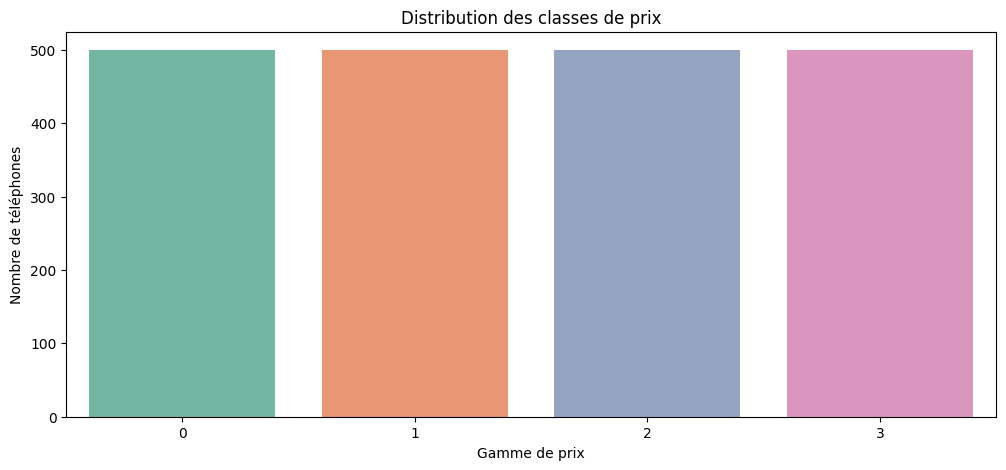

In [25]:
plt.figure(figsize=(12, 5))
sns.countplot(x=target, data=df, palette='Set2')
plt.title('Distribution des classes de prix')
plt.xlabel('Gamme de prix')
plt.ylabel('Nombre de téléphones')
plt.show()

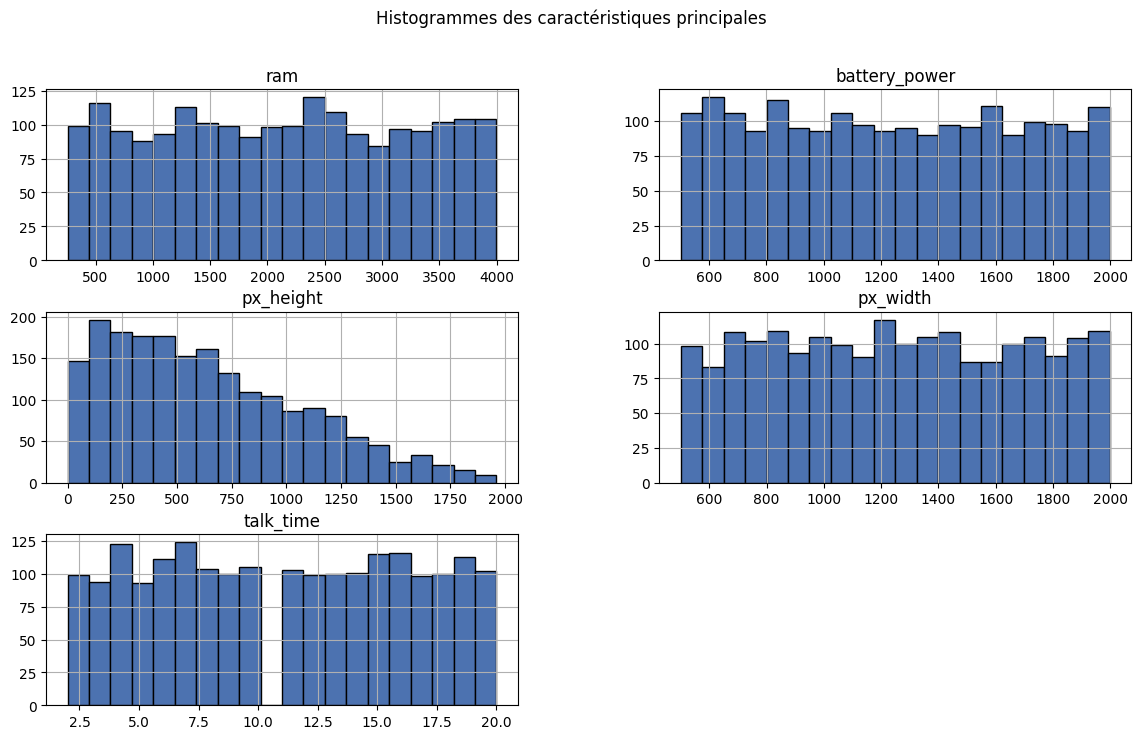

In [26]:
selected = ['ram', 'battery_power', 'px_height', 'px_width', 'talk_time']
df[selected].hist(figsize=(14, 8), bins=20, color='#4c72b0', edgecolor='black')
plt.suptitle('Histogrammes des caractéristiques principales')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17600\317361265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='pastel')
C:\Users\USER\AppData\Local\Temp\ipykernel_17600\317361265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='pastel')
C:\Users\USER\AppData\Local\Temp\ipykernel_17600\317361265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, palette='pastel')
C:\Users\USER\AppData\Local\Temp\ipykernel_17600\317361265.py:4: FutureWarning: 



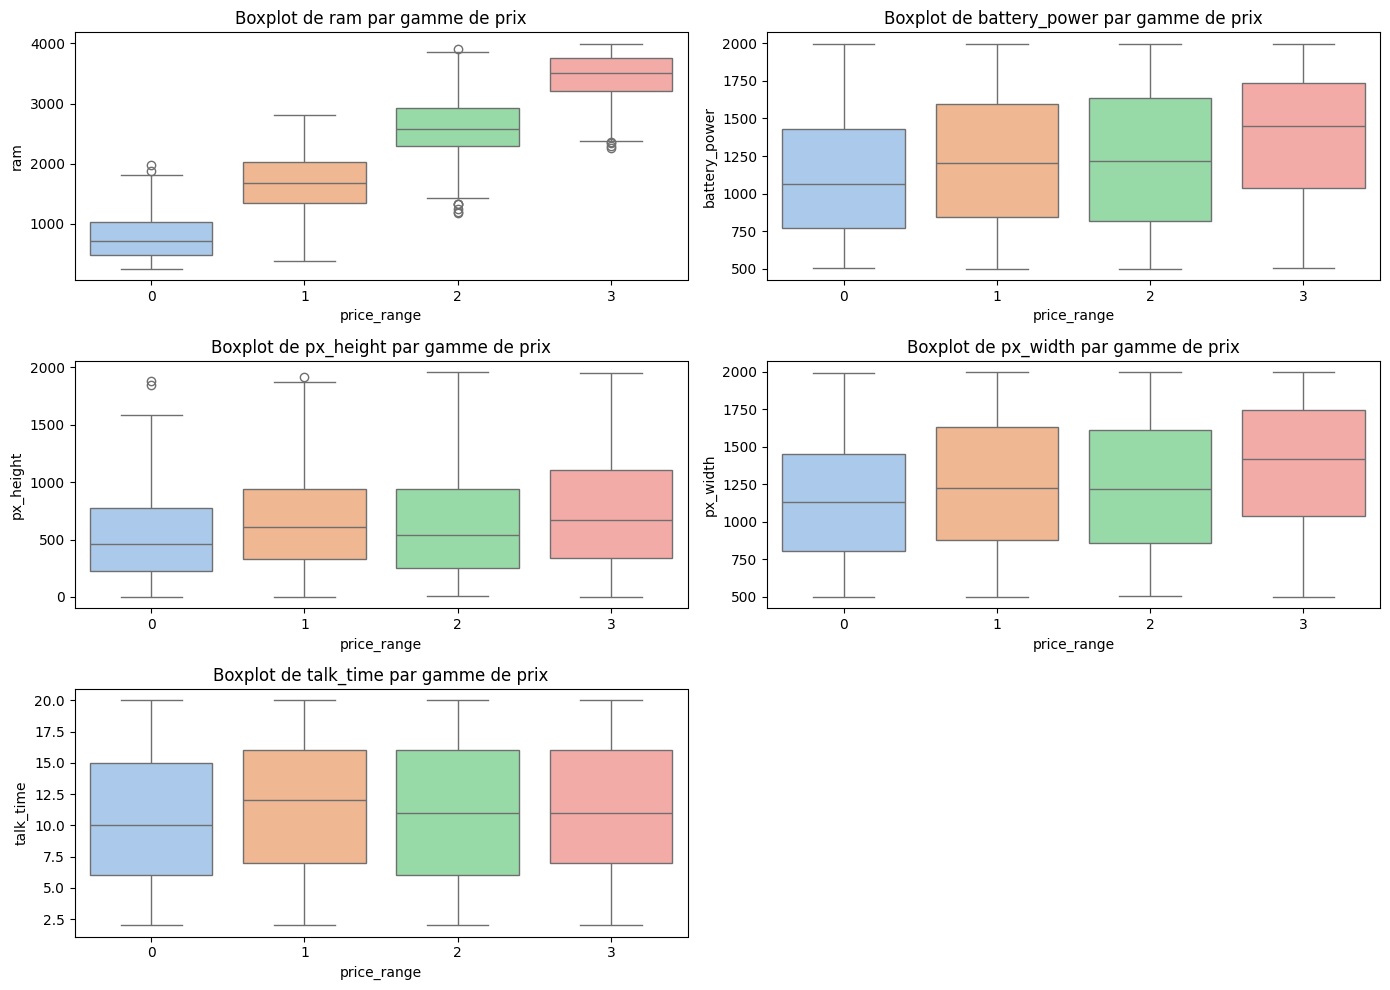

In [27]:
plt.figure(figsize=(14, 10))
for idx, col in enumerate(selected, 1):
    plt.subplot(3, 2, idx)
    sns.boxplot(x=target, y=col, data=df, palette='pastel')
    plt.title(f'Boxplot de {col} par gamme de prix')
plt.tight_layout()
plt.show()

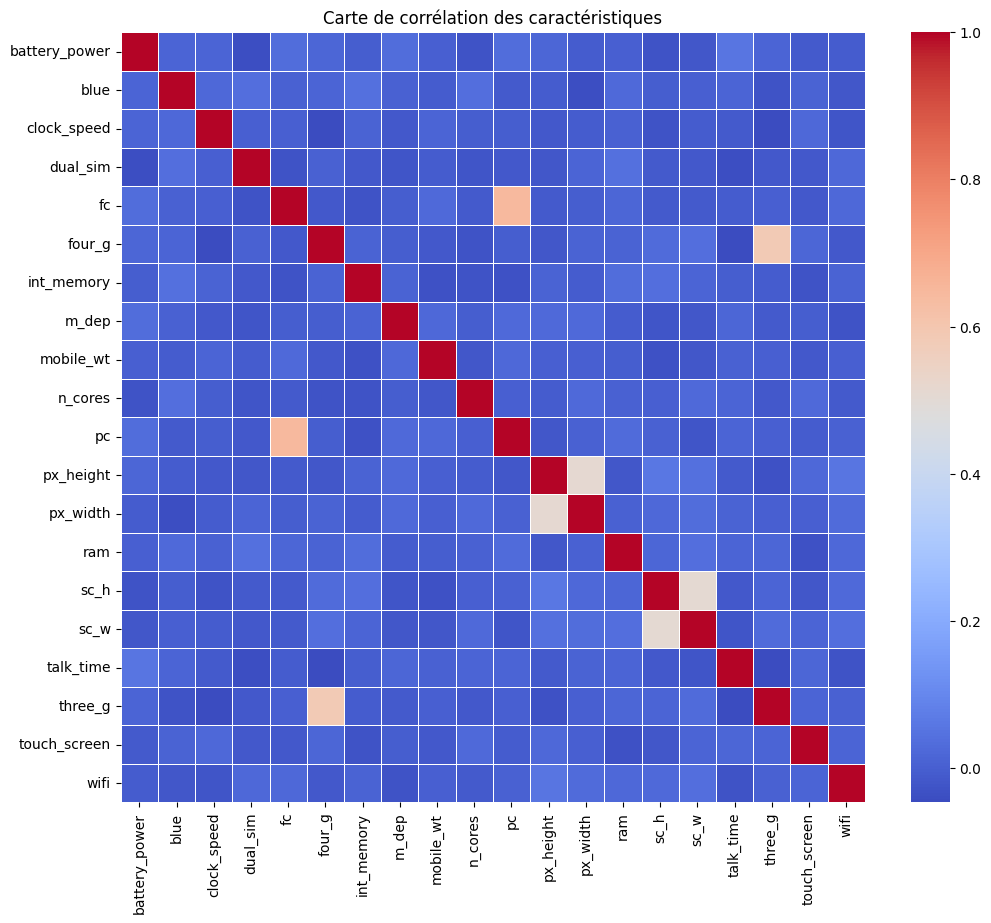

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Carte de corrélation des caractéristiques')
plt.show()

## 5. Synthèse des idées et conclusion

- Les variables `ram`, `battery_power`, `px_height` et `px_width` montrent de fortes corrélations avec `price_range`.
- Les résultats de l'ANOVA indiquent que de nombreuses caractéristiques ont des différences de moyenne significatives entre les classes de prix.
- Les visualisations montrent que la RAM et la puissance de la batterie augmentent généralement avec des gammes de prix plus élevées.
- Ces facteurs sont probablement des déterminants clés de la classification du prix des téléphones mobiles.

> Conclusion : l'analyse révèle que les caractéristiques matérielles liées à la performance et à l'écran sont les plus influentes pour prédire la gamme de prix d'un mobile.